In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dem = rasterio.open("India_DEM.tif")

# Read DEM and keep NoData as a mask
elevation_masked = dem.read(1, masked=True)

# Create a floating-point version for calculations
elevation = elevation_masked.astype("float32").filled(np.nan)

print("CRS:", dem.crs)
print("Resolution:", dem.res)
print("Width:", dem.width)
print("Height:", dem.height)
print("Minimum Elevation:", elevation_masked.min())
print("Maximum Elevation:", elevation_masked.max())

CRS: EPSG:4326
Resolution: (0.008333333333333335, 0.008333333333333335)
Width: 3515
Height: 3641
Minimum Elevation: -47
Maximum Elevation: 8253


In [3]:
longitude = np.linspace(
    dem.bounds.left,
    dem.bounds.right,
    dem.width
)

latitude = np.linspace(
    dem.bounds.top,
    dem.bounds.bottom,
    dem.height
)

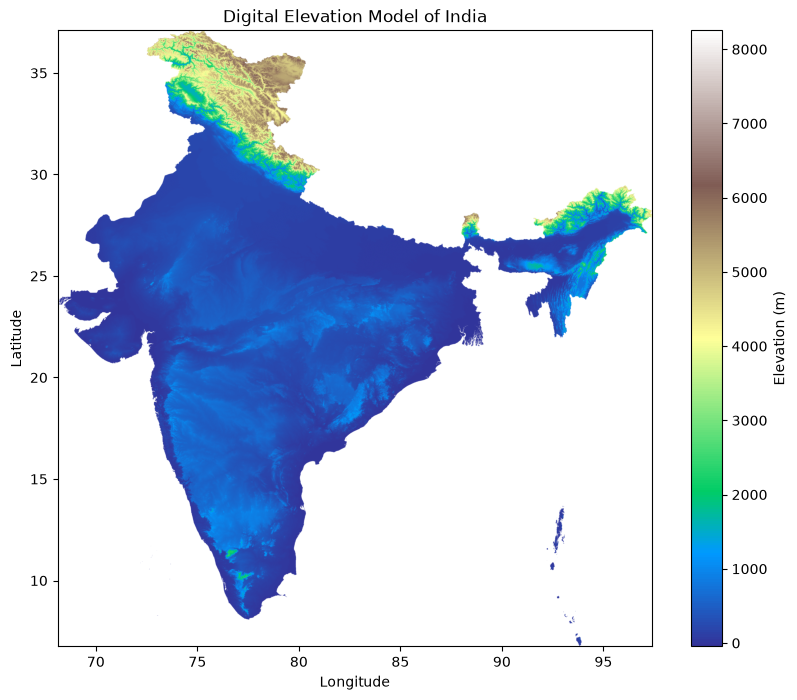

In [4]:
plt.figure(figsize=(10, 8))

plt.imshow(
    elevation_masked,
    cmap="terrain",
    extent=[
        dem.bounds.left,
        dem.bounds.right,
        dem.bounds.bottom,
        dem.bounds.top
    ]
)

plt.colorbar(label="Elevation (m)")

plt.title("Digital Elevation Model of India")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("DEM.png", dpi=600, bbox_inches="tight")
plt.show()

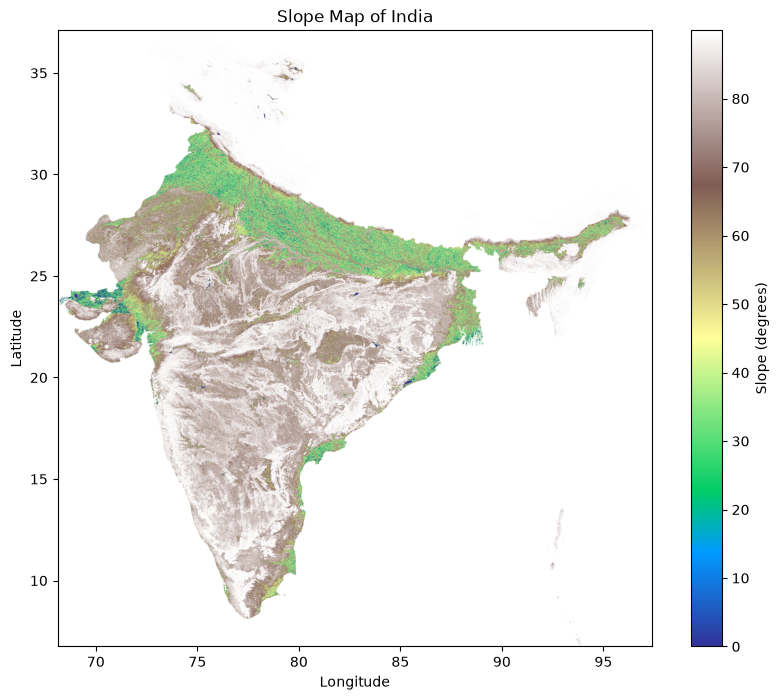

In [5]:
dy, dx = np.gradient(elevation)

slope = np.degrees(
    np.arctan(
        np.sqrt(dx**2 + dy**2)
    )
)

plt.figure(figsize=(10, 8))

plt.imshow(
    slope,
    cmap="terrain",
    extent=[
        dem.bounds.left,
        dem.bounds.right,
        dem.bounds.bottom,
        dem.bounds.top
    ]
)

plt.colorbar(label="Slope (degrees)")

plt.title("Slope Map of India")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("Slope.png", dpi=600, bbox_inches="tight")
plt.show()

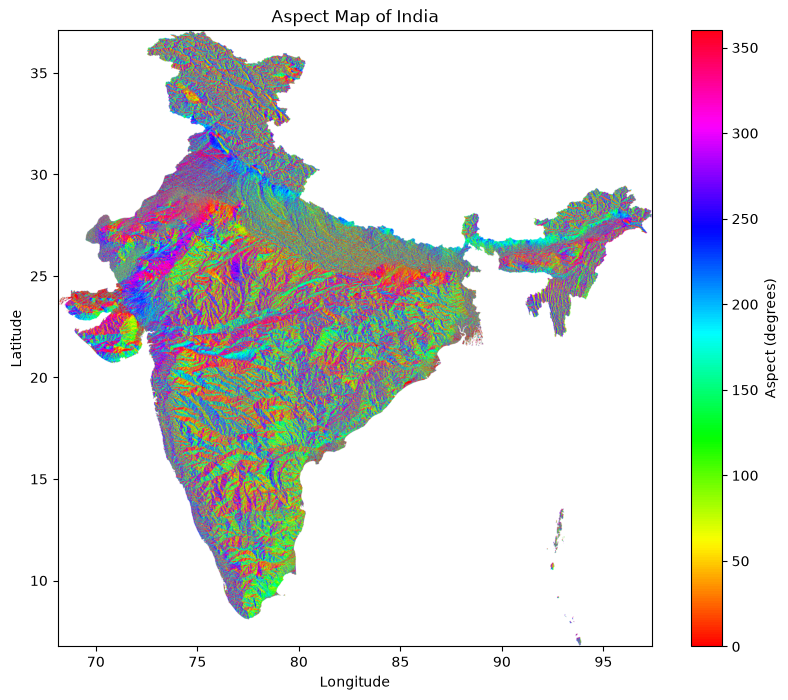

In [6]:
aspect = np.degrees(
    np.arctan2(-dx, dy)
)

aspect = (aspect + 360) % 360

plt.figure(figsize=(10, 8))

plt.imshow(
    aspect,
    cmap="hsv",
    vmin=0,
    vmax=360,
    extent=[
        dem.bounds.left,
        dem.bounds.right,
        dem.bounds.bottom,
        dem.bounds.top
    ]
)

plt.colorbar(label="Aspect (degrees)")

plt.title("Aspect Map of India")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("Aspect.png", dpi=600, bbox_inches="tight")
plt.show()

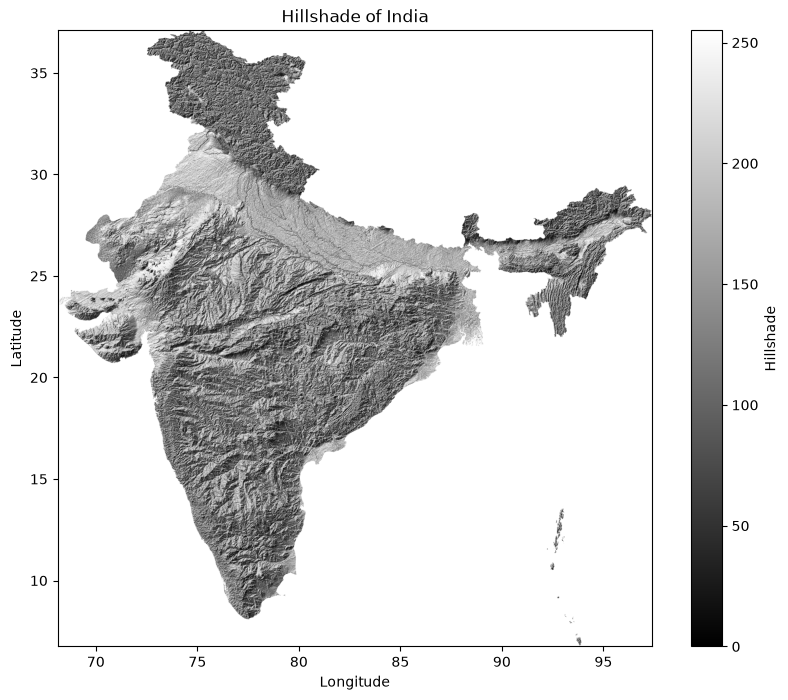

In [7]:
azimuth = 315
altitude = 45

slope_rad = np.radians(slope)
aspect_rad = np.radians(aspect)

azimuth_rad = np.radians(azimuth)
altitude_rad = np.radians(altitude)



hillshade = (
    np.sin(altitude_rad) * np.cos(slope_rad)
    +
    np.cos(altitude_rad)
    * np.sin(slope_rad)
    * np.cos(azimuth_rad - aspect_rad)
)

hillshade = (
    (hillshade - np.nanmin(hillshade))
    /
    (np.nanmax(hillshade) - np.nanmin(hillshade))
    * 255
)

plt.figure(figsize=(10, 8))

plt.imshow(
    hillshade,
    cmap="gray",
    extent=[
        dem.bounds.left,
        dem.bounds.right,
        dem.bounds.bottom,
        dem.bounds.top
    ]
)

plt.colorbar(label="Hillshade")

plt.title("Hillshade of India")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("Hillshade.png", dpi=600, bbox_inches="tight")
plt.show()


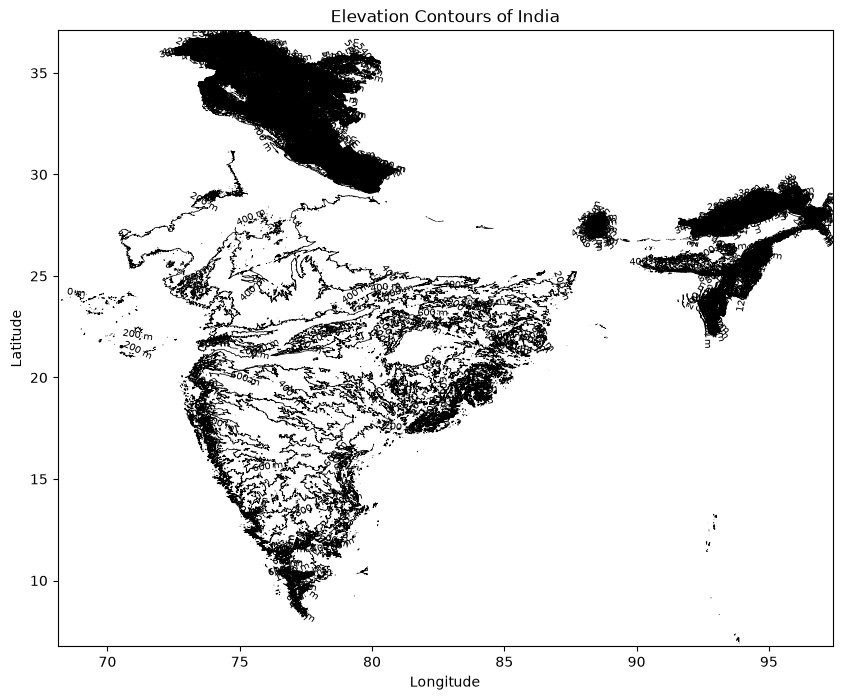

In [8]:
X, Y = np.meshgrid(
    longitude,
    latitude
)

levels = np.arange(0, 8500, 200)

plt.figure(figsize=(10, 8))

contours = plt.contour(
    X,
    Y,
    elevation_masked,
    levels=levels,
    colors="black",
    linewidths=0.5
)

plt.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%d m"
)

plt.title("Elevation Contours of India")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("Contours.png", dpi=600, bbox_inches="tight")
plt.show()

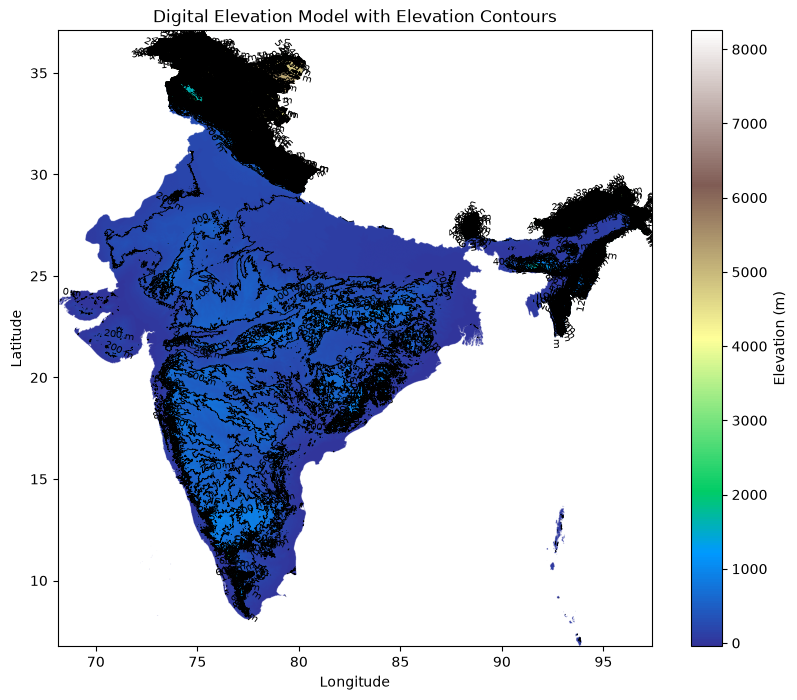

In [9]:
plt.figure(figsize=(10, 8))

# Plot DEM
im = plt.imshow(
    elevation_masked,
    cmap="terrain",
    extent=[
        dem.bounds.left,
        dem.bounds.right,
        dem.bounds.bottom,
        dem.bounds.top
    ]
)

# Contour levels
levels = np.arange(0, 8500, 200)

# Plot contours
contours = plt.contour(
    X,
    Y,
    elevation_masked,
    levels=levels,
    colors="black",
    linewidths=0.5
)

# Add contour labels
plt.clabel(
    contours,
    inline=True,
    fontsize=7,
    fmt="%d m"
)

# Colorbar for DEM
plt.colorbar(
    im,
    label="Elevation (m)"
)

plt.title("Digital Elevation Model with Elevation Contours")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("DEM_contours.png", dpi=600, bbox_inches="tight")
plt.show()